[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OceanNetworksCanada/python-community-notebooks/blob/main/workflows/vertical-profiling/bacvp_ctd_up_profiles.ipynb)

In [ ]:
!uv pip install -q gsw onc xarray

In [ ]:
# Bootstrap cell
import sys
from pathlib import Path
import os

def in_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

def setup_repo_for_shared_imports():
    """
    Locate (or clone, in Colab) the notebook repository and add it to ``sys.path``.

    Notes:
        - In Colab, this ensures the repository exists at
          ``/content/python-community-notebooks`` by cloning it if needed.
        - In local environments, this searches upward from the current working
          directory for ``shared`` to identify the repo root.
        - If a repo root is found, it is prepended to ``sys.path`` to enable
          imports from the repository (e.g., ``shared`` modules).
    """
    repo_dir: Path | None = None

    if in_colab():
        repo_dir = Path('/content/python-community-notebooks')
        if not repo_dir.exists():
            !git clone --depth 1 https://github.com/OceanNetworksCanada/python-community-notebooks.git /content/python-community-notebooks
    else:
        cwd = Path.cwd().resolve()
        for candidate in [cwd, *cwd.parents]:
            if (candidate / 'shared').exists():
                repo_dir = candidate
                break

    if repo_dir is not None and str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))



def init_token():   
    """
    Initialize the ONC_TOKEN environment variable.

    Notes:
        - If in Colab, add your ONC_TOKEN secrets by clicking the key icon on the left sidebar
        - If in local, create .env file in the root directory, and add ONC_TOKEN=XXX in your .env file
    """
    if in_colab():
        from google.colab import userdata
        os.environ['ONC_TOKEN'] = userdata.get('ONC_TOKEN')
    else:
        from dotenv import load_dotenv
        load_dotenv()

init_token()
setup_repo_for_shared_imports()

In [ ]:
from datetime import datetime
import gsw
import matplotlib.pyplot as plt
import pandas as pd
from onc import ONC

from shared.IanTBlack_common import format_datetime, convert_scalar_data, identify_profiles


In [4]:
onc = ONC()

In [5]:
date_from = datetime(2025,6,14,22,0,0,0)
date_to = datetime(2025,6,15,23,59,59,999999)

In [6]:
params = {'locationCode': 'BACVP',
          'deviceCategoryCode': 'DC90',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False,
          'propertyCode': 'length'}
json_response = onc.getScalardata(filters = params, allPages=True)
cl = convert_scalar_data(json_response_data=json_response, out_as = 'xarray')
cable_length = cl.cable_length
cable_length = cable_length.dropna(dim = 'time')

In [7]:
ups = identify_profiles(cable_length, profile_direction='up', max_allowed_std=0.05)
ups = [up for up in ups if (up['dateTo'] - up['dateFrom']).total_seconds() > 60*3] # Keep only profiles longer than 3 minutes.

In [8]:
params = {'locationCode': 'BACVP',
          'deviceCategoryCode': 'CTD',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
ctd = convert_scalar_data(json_response_data=json_response, out_as = 'xarray')

Data quantity is greater than the row limit and will be downloaded in multiple pages.
Estimated approx. 4 pages in total.
Estimated approx. 26 seconds to complete for the rest of the pages.

   (100000 samples) Downloading page 2...
   (200000 samples) Downloading page 3...
   (299999 samples) Downloading page 4...
   (363276 samples) Completed in 34 seconds.


/tmp/ipykernel_1291448/3307007043.py:70: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat(dfs, axis=1)


In [9]:
lat = 48.427455
lon = -126.174124

In [10]:
profiles = []
for up in ups:
    ctd_pro = ctd.sel(time = slice(up['dateFrom'],up['dateTo']))

    ctd_pro = ctd_pro.sortby('time')
    ctd_pro = ctd_pro.dropna(dim = 'time', how = 'all')
    ctd_pro = ctd_pro.assign_coords({'profile_id': [pd.to_datetime(ctd_pro.time.min().values).strftime('%Y%m%dT%H%M%SZ')]})
    ctd_pro = ctd_pro.rolling({'time': 5}, center=True, min_periods=1).median(skipna = True) # Apply a rolling median to smooth the data.

    # Convert cond from S/m to mS/cm for GSW.
    ctd_pro['conductivity'] = ctd_pro['conductivity'] * 10
    ctd_pro['conductivity'].attrs['uom'] = 'mS/cm'
    ctd_pro['conductivity'].attrs['unitOfMeasure'] = 'mS/cm'

    ctd_pro['practical_salinity'] = gsw.SP_from_C(ctd_pro.conductivity, ctd_pro.temperature, ctd_pro.pressure)
    ctd_pro['absolute_salinity'] = gsw.SA_from_SP(ctd_pro.practical_salinity, ctd_pro.temperature,
                                                            lon =  lon, lat =  lat)
    ctd_pro['conservative_temperature'] = gsw.CT_from_t(ctd_pro.absolute_salinity, ctd_pro.temperature, ctd_pro.pressure)
    ctd_pro['density'] = gsw.density.rho(ctd_pro.absolute_salinity, ctd_pro.conservative_temperature, ctd_pro.pressure)
    ctd_pro['potential_density'] = gsw.sigma0(ctd_pro.absolute_salinity, ctd_pro.conservative_temperature)
    ctd_pro['depth'] = gsw.z_from_p(ctd_pro.pressure, lat)*-1

    profiles.append(ctd_pro)

Text(0.5, 0, 'Sea Water Potential Density ($\\frac{kg}{m^3}$)')

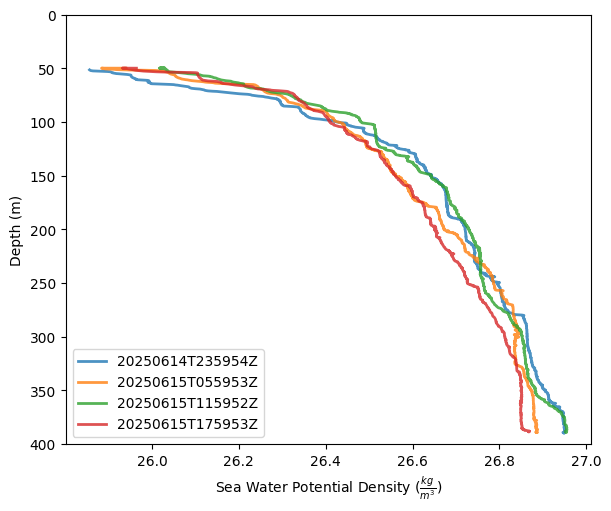

In [11]:
fig, ax = plt.subplots(1,1, figsize = (6,5), constrained_layout = True)

for i in range(len(profiles)):
    pro = profiles[i]
    ax.plot(pro.potential_density, pro.depth, alpha = 0.8, label = pro.profile_id.values, linewidth = 2)

ax.legend(loc = 'lower left')

ax.set_ylim(0,400)

ax.invert_yaxis()
ax.set_ylabel('Depth (m)')
ax.set_xlabel(r'Sea Water Potential Density ($\frac{kg}{m^3}$)')
